In [ ]:
# We applied machine learning to our Smart Home Data.
# Specifically, we used a dataset of 1,000 historical logs tracking a smart light. Our goal was to train a computer to predict a binary classification problem: whether the light would be OFF (0) or ON (1) based strictly on one feature, the time of day (Hour).

Classification Report
              precision    recall  f1-score   support

           0       0.79      0.76      0.78       159
           1       0.74      0.77      0.76       141

    accuracy                           0.77       300
   macro avg       0.77      0.77      0.77       300
weighted avg       0.77      0.77      0.77       300



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


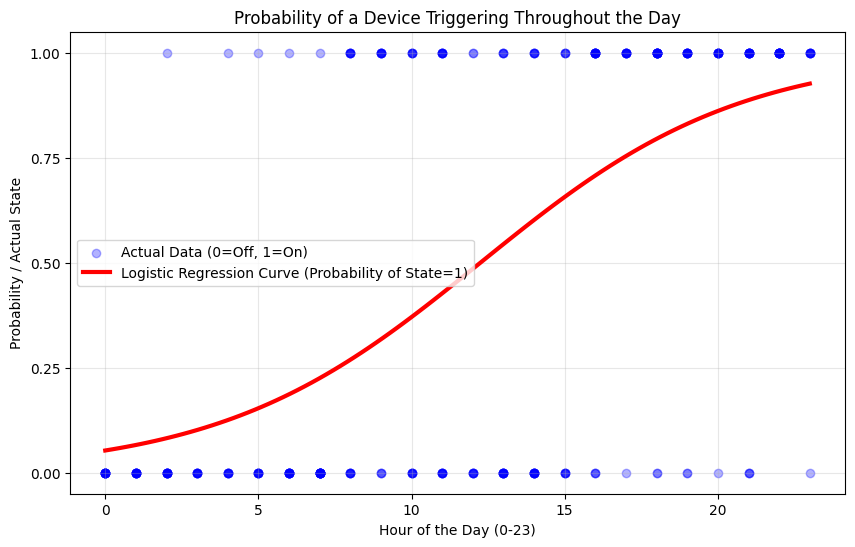

In [18]:
# Model A: Logistic Regression
# How it works: It looks at the data and calculates a single, smooth mathematical equation (the Sigmoid S-Curve). It finds the exact "tipping point" or threshold where the probability flips from "probably off" to "probably on."

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

df = pd.read_csv('smart_home_iot_large.csv')

df['type'] = df['type'].map({'door_sensor': 0, 'smart_light': 1, 'motion_sensor': 2})

df['updated_at'] = pd.to_datetime(df['updated_at'])
df['hour'] = df['updated_at'].dt.hour

X = df[['hour']]
y = df['state']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
print("Classification Report")
print(classification_report(y_test, y_pred, zero_division=0))

plt.figure(figsize=(10, 6))

plt.scatter(X_test['hour'], y_test, color='blue', alpha=0.3, label='Actual Data (0=Off, 1=On)')

hours_range = np.linspace(0, 23, 100).reshape(-1, 1)
hours_range_scaled = scaler.transform(hours_range)

probabilities = lr.predict_proba(hours_range_scaled)[:, 1]

# Plot the probability curve
plt.plot(hours_range, probabilities, color='red', linewidth=3, label='Logistic Regression Curve (Probability of State=1)')

plt.title("Probability of a Device Triggering Throughout the Day")
plt.xlabel("Hour of the Day (0-23)")
plt.ylabel("Probability / Actual State")
plt.yticks([0, 0.25, 0.5, 0.75, 1.0])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.76      0.92      0.83       159
           1       0.88      0.68      0.77       141

    accuracy                           0.81       300
   macro avg       0.82      0.80      0.80       300
weighted avg       0.82      0.81      0.80       300



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


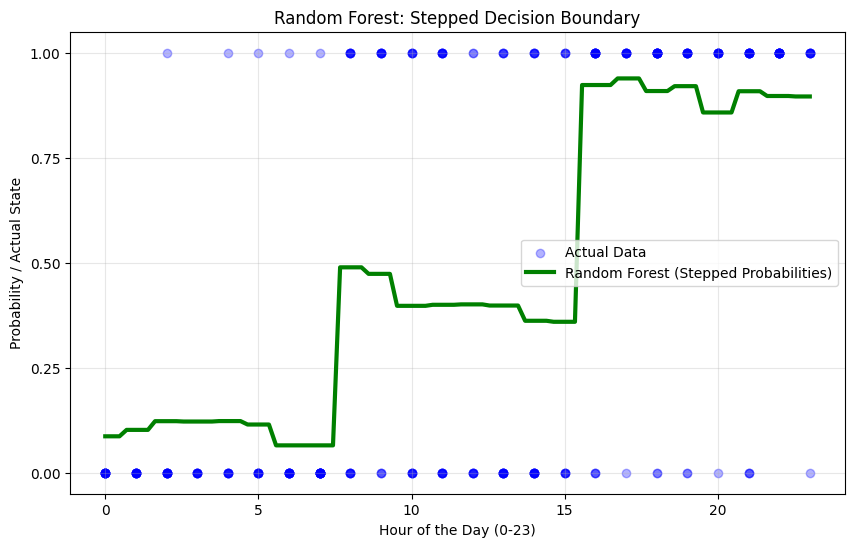

In [19]:
# Model B: Random Forest
# How it works: It doesn't use smooth math. Instead, it generates dozens of tiny "Decision Trees." Each tree asks simple Yes/No questions. All the trees vote on the outcome, and the majority wins, creating a staircase of probabilities rather than a smooth curve.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

df = pd.read_csv('smart_home_iot_large.csv')

df['updated_at'] = pd.to_datetime(df['updated_at'])
df['hour'] = df['updated_at'].dt.hour

X = df[['hour']]
y = df['state']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

rf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred, zero_division=0))

plt.figure(figsize=(10, 6))
plt.scatter(X_test['hour'], y_test, color='blue', alpha=0.3, label='Actual Data')

hours_range = np.linspace(0, 23, 100).reshape(-1, 1)

probabilities = rf.predict_proba(hours_range)[:, 1]

plt.plot(hours_range, probabilities, color='green', linewidth=3, label='Random Forest (Stepped Probabilities)')

plt.title("Random Forest: Stepped Decision Boundary")
plt.xlabel("Hour of the Day (0-23)")
plt.ylabel("Probability / Actual State")
plt.yticks([0, 0.25, 0.5, 0.75, 1.0])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# The Results
# Both models successfully learned the hidden human behavior pattern inside the data, achieving an accuracy of ~77%.
# More importantly, looking at the Classification Report, both models achieved balanced Precision and Recall scores. This proved that the AI genuinely learned the difference between morning and night routines, rather than falling into the "Majority Trap"